In [17]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

import os
import re
from pathlib import Path

import matplotlib.pyplot as plt


In [18]:
# -----------------------------
# 1. Read the two csv files
# -----------------------------
PROJECT_ROOT = Path().resolve().parents[0]
DATA_DIR = PROJECT_ROOT / "data"
DATA_DIR_2 = PROJECT_ROOT / "kmeans_k5_outputs_split"

label_df = pd.read_csv(DATA_DIR / "player_residual_labels_with_majority_vote.csv")
feature_df = pd.read_csv(DATA_DIR_2 / "player_feature_table_1999_2019_clustered_k5.csv")

# -----------------------------
# 2. Make the ID column name the same
# -----------------------------
feature_df = feature_df.rename(columns={"Player_ID": "PLAYER_ID"})

# -----------------------------
# 3. Keep only the columns we need from label file
# -----------------------------
label_keep = label_df[["PLAYER_ID", "PLAYER_NAME", "final_label", "final_label_num"]].copy()

# -----------------------------
# 4. Merge
#    only keep players that exist in both tables
# -----------------------------
merged_df = feature_df.merge(
    label_keep,
    on="PLAYER_ID",
    how="inner"
)


merged_df = merged_df.drop(columns=["PLAYER_NAME"])

# -----------------------------
# 6. Print summary
# -----------------------------
print("Original feature table rows:", len(feature_df))
print("Original major vote rows:", len(label_df))
print("Merged rows:", len(merged_df))
# print("New file saved as: player_feature_table_with_major_vote_labels.csv")

Original feature table rows: 1058
Original major vote rows: 655
Merged rows: 646


## **Main type of logistic regression**

This is the muti logistic regression model we should use, the detail is:

model = LogisticRegression(
    solver="lbfgs",
    max_iter=5000
)

**It doesn't use class weight  and solver as the ibfgs.**

As in the result, you can see the recall and F1-scores. Not too bad.
This is the best result i can achieve. I have tired to use RandomForest, change the labe rule in label_player.ipynb, use the linear regression instead of ridge regression to find expected scores and etc.... No one give the result better than this one.

In [19]:
# =========================================================
# 1. Read data
# =========================================================
df = merged_df

# =========================================================
# 2. Define target and predictors
# =========================================================
target_col = "final_label_num"

numeric_features = [
    "seasons_played",
    "total_games",
    "total_minutes",
    "mean_min",
    "pct_20plus_min",
    "pct_25plus_min",
    "pct_30plus_min",

    "fg_pct_4yr",
    "fg3_pct_4yr",
    "ft_pct_4yr",
    "ts_pct_4yr",
    "fg3a_rate_4yr",
    "ftr_4yr",
    "ast_tov_ratio_4yr",

    "pts_per36_4yr",
    "reb_per36_4yr",
    "ast_per36_4yr",
    "stl_per36_4yr",
    "blk_per36_4yr",
    "tov_per36_4yr",
    "fga_per36_4yr",
    "fta_per36_4yr",
    "usage_proxy_per36_4yr",

    "games_slope",
    "mpg_slope",
    "pts_per36_slope",
    "reb_per36_slope",
    "ast_per36_slope",
    "ts_pct_slope",
    "fg3a_rate_slope",
    "ftr_slope",
    "pct_25plus_min_slope",
    "pct_30plus_min_slope",

    "mpg_delta_4_1",
    "pts_per36_delta_4_1",
    "ts_pct_delta_4_1",

    "min_std",
    "points_game_std",
    "minutes_game_std",
    "std_games_across_seasons",
    "recent_minutes_share",
    "late_vs_early_minutes_ratio",

    "own_cluster_distance_k5"
]

categorical_features = [
    "kmeans_cluster_k5"
]

all_features = numeric_features + categorical_features

# Keep only needed columns and drop rows with missing y
df_model = df[all_features + [target_col]].copy()
df_model = df_model.dropna(subset=[target_col])

# Make sure y is integer
df_model[target_col] = df_model[target_col].astype(int)

X = df_model[all_features]
y = df_model[target_col]

# =========================================================
# 3. Train/test split
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================================================
# 4. Preprocessing
#    - numeric: median impute + standardize
#    - categorical: most frequent impute + one-hot encode
# =========================================================
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# =========================================================
# 5. Multinomial logistic regression model
# =========================================================
model = LogisticRegression(
    solver="lbfgs",
    max_iter=5000
)

clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", model)
])

# Fit model
clf.fit(X_train, y_train)

# =========================================================
# 6. Prediction and evaluation
# =========================================================
y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")
cm = confusion_matrix(y_test, y_pred)

print("=" * 60)
print("Multinomial Logistic Regression Results")
print("=" * 60)
print(f"Accuracy   : {acc:.4f}")
print(f"Macro-F1   : {macro_f1:.4f}")
print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))

Multinomial Logistic Regression Results
Accuracy   : 0.5077
Macro-F1   : 0.4727

Confusion Matrix:
[[14  5  8]
 [ 7 11 25]
 [10  9 41]]

Classification Report:
              precision    recall  f1-score   support

           0     0.4516    0.5185    0.4828        27
           1     0.4400    0.2558    0.3235        43
           2     0.5541    0.6833    0.6119        60

    accuracy                         0.5077       130
   macro avg     0.4819    0.4859    0.4727       130
weighted avg     0.4951    0.5077    0.4897       130



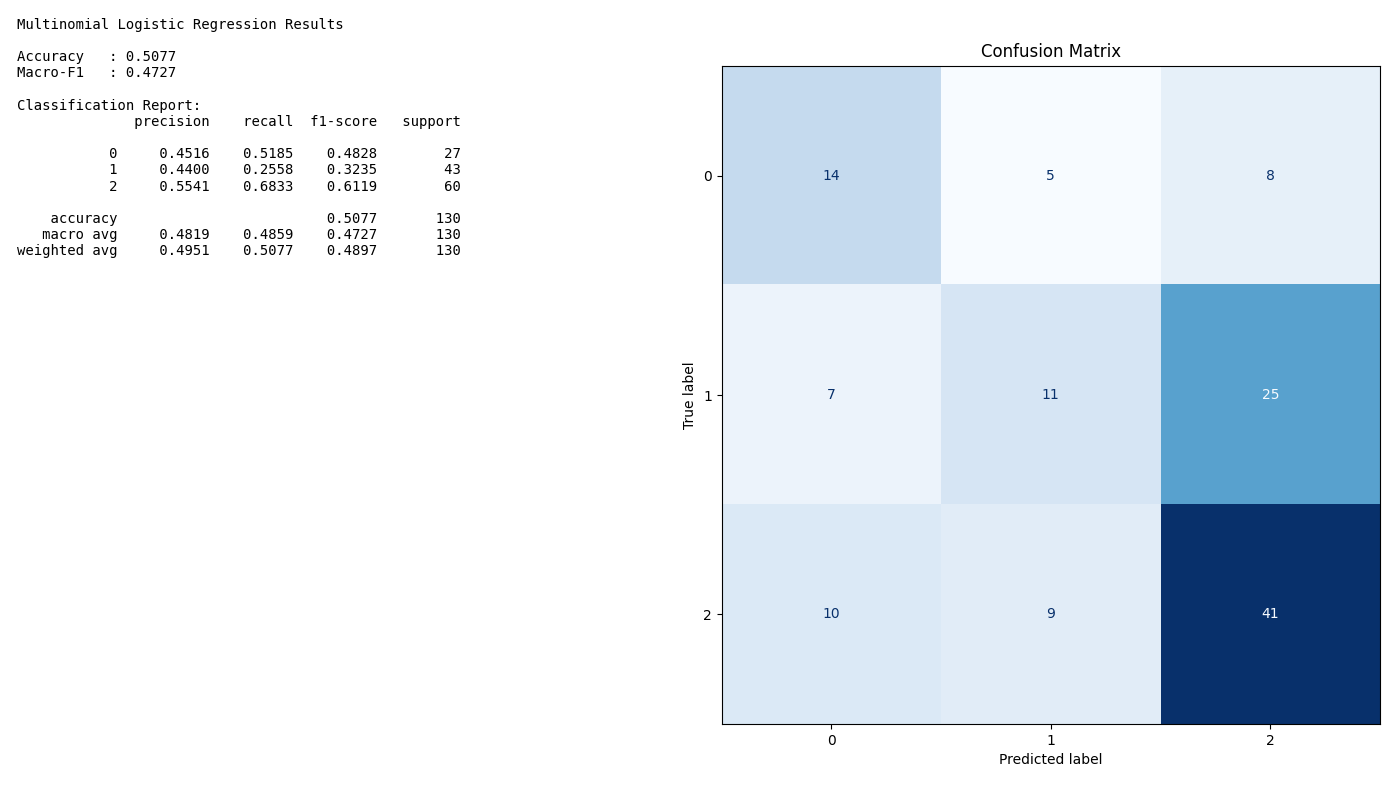

In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, ConfusionMatrixDisplay

# Assume you already have:
# y_test, y_pred

# Calculate metrics
acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred, digits=4)

# Build summary text
summary_text = (
    "Multinomial Logistic Regression Results\n\n"
    f"Accuracy   : {acc:.4f}\n"
    f"Macro-F1   : {macro_f1:.4f}\n\n"
    "Classification Report:\n"
    f"{report}"
)

# Create one figure with 2 parts
fig = plt.figure(figsize=(14, 8))

# Left side: text
ax1 = fig.add_subplot(1, 2, 1)
ax1.axis("off")
ax1.text(
    0.01, 0.99,
    summary_text,
    va="top",
    ha="left",
    family="monospace",
    fontsize=10
)

# Right side: confusion matrix
ax2 = fig.add_subplot(1, 2, 2)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1, 2])
disp.plot(ax=ax2, cmap="Blues", colorbar=False)
ax2.set_title("Confusion Matrix")

plt.tight_layout()
fig_path = DATA_DIR / f"multinomial_logistic_results_one.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()


In [15]:
# =========================================================
# 7. Get feature names after preprocessing
# =========================================================
feature_names = clf.named_steps["preprocessor"].get_feature_names_out()

# Clean feature names a little
feature_names = [name.replace("num__", "").replace("cat__", "") for name in feature_names]

# =========================================================
# 8. Extract coefficients for feature importance
#    coef_ shape = [n_classes, n_features]
# =========================================================
coef_matrix = clf.named_steps["model"].coef_
class_labels = clf.named_steps["model"].classes_

# Save raw coefficient table
coef_df = pd.DataFrame(
    coef_matrix,
    index=[f"class_{c}" for c in class_labels],
    columns=feature_names
).T

print("\nRaw coefficient table (first 20 rows):")
print(coef_df.head(20))



Raw coefficient table (first 20 rows):
                    class_0   class_1   class_2
seasons_played     0.148470 -0.215243  0.066773
total_games        0.177826 -0.069616 -0.108210
total_minutes     -0.131164  0.333751 -0.202587
mean_min          -0.161563 -0.322850  0.484413
pct_20plus_min     0.297166 -0.001857 -0.295310
pct_25plus_min    -0.079389  0.141437 -0.062048
pct_30plus_min    -0.235670 -0.080208  0.315879
fg_pct_4yr         0.394494 -0.036327 -0.358168
fg3_pct_4yr       -0.306186  0.107965  0.198220
ft_pct_4yr         0.067535  0.035017 -0.102552
ts_pct_4yr        -0.003763 -0.188318  0.192081
fg3a_rate_4yr      0.904429 -0.332562 -0.571867
ftr_4yr            0.058645  0.082325 -0.140970
ast_tov_ratio_4yr  0.122346 -0.289418  0.167072
pts_per36_4yr     -0.527711  0.650840 -0.123129
reb_per36_4yr      0.037196  0.090030 -0.127226
ast_per36_4yr     -0.168538  0.438856 -0.270318
stl_per36_4yr      0.063199 -0.011514 -0.051686
blk_per36_4yr      0.154937 -0.100251 -0.054686


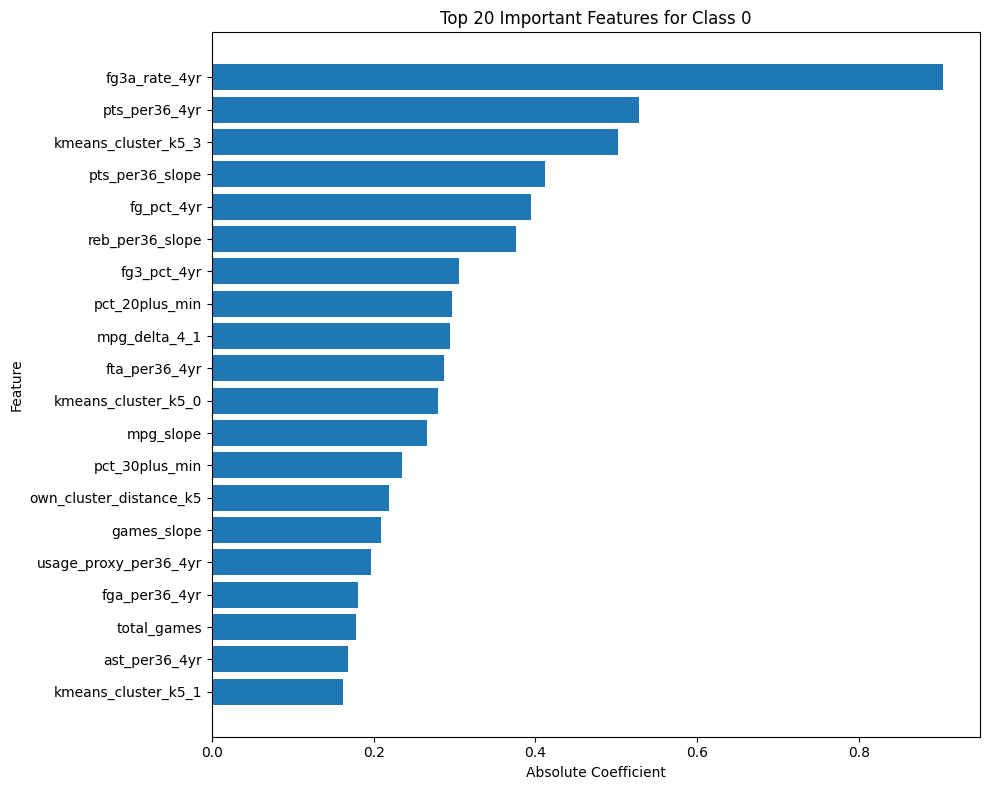

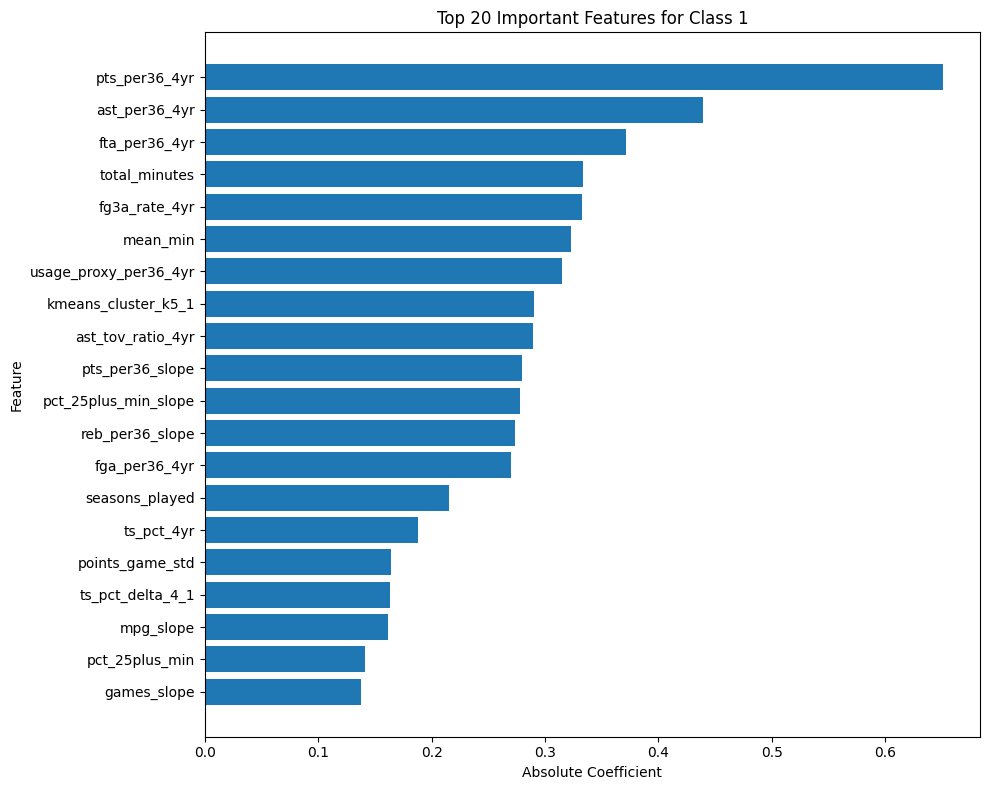

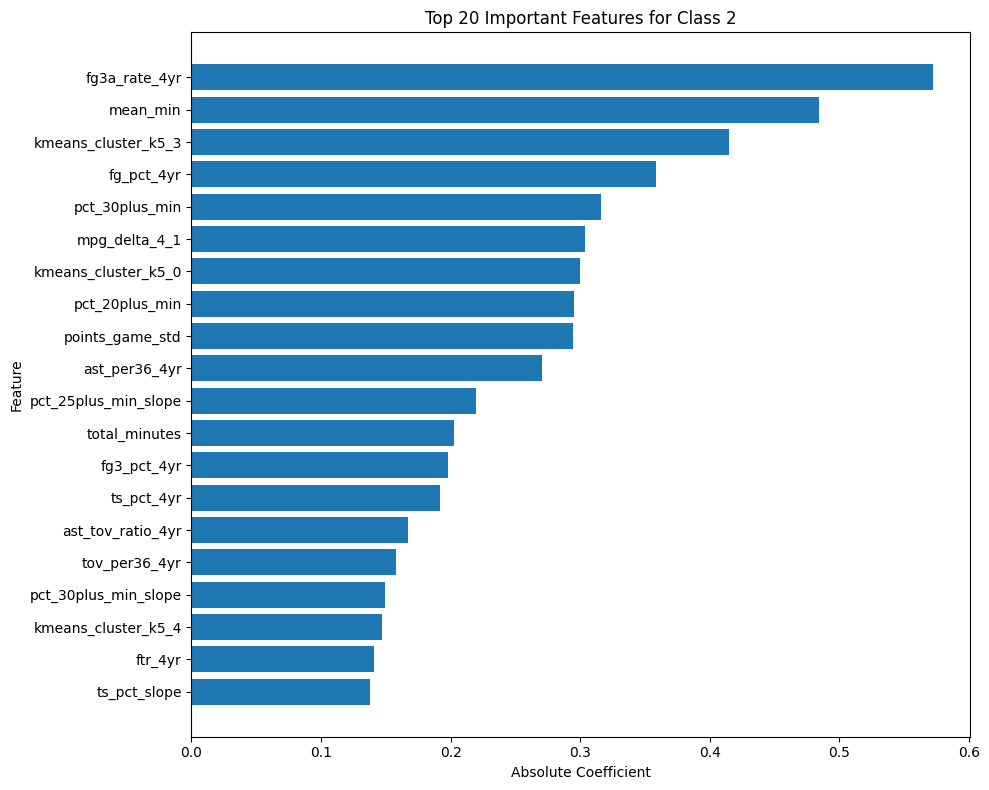

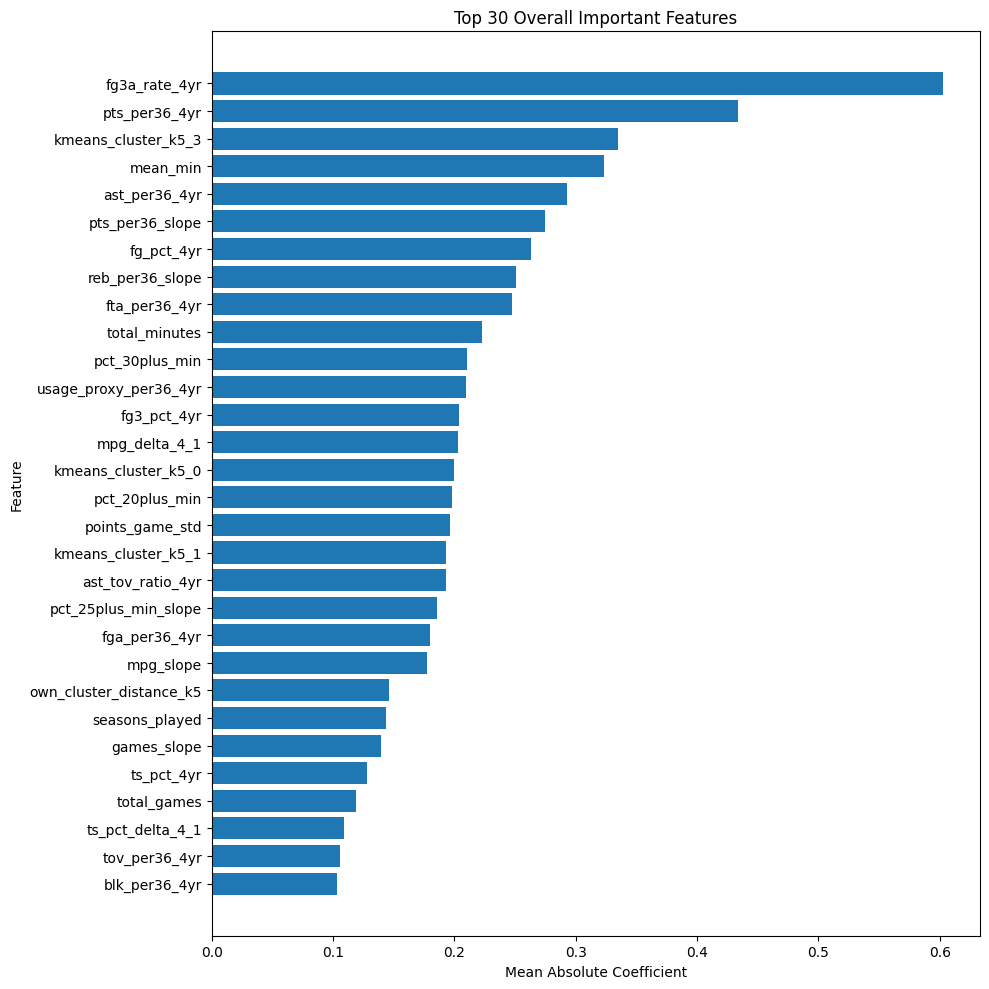

In [16]:
# =========================================================
# 9. Feature importance by class -> plot and save images
#    Larger absolute coefficient = stronger influence
# =========================================================

for i, class_label in enumerate(class_labels):
    class_importance = pd.DataFrame({
        "feature": feature_names,
        "coefficient": coef_matrix[i],
        "abs_coefficient": np.abs(coef_matrix[i])
    }).sort_values("abs_coefficient", ascending=False)

    # Keep top 20 features
    top_n = 20
    plot_df = class_importance.head(top_n).copy()

    # Reverse for cleaner horizontal bar plot (largest at top)
    plot_df = plot_df.iloc[::-1]

    plt.figure(figsize=(10, 8))
    plt.barh(plot_df["feature"], plot_df["abs_coefficient"])
    plt.xlabel("Absolute Coefficient")
    plt.ylabel("Feature")
    plt.title(f"Top {top_n} Important Features for Class {class_label}")
    plt.tight_layout()

    # Save figure
    fig_path = DATA_DIR / f"feature_importance_class_{class_label}.png"
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()



# =========================================================
# 10. Overall feature importance across classes -> plot
#     Mean absolute coefficient across all classes
# =========================================================
overall_importance = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_coefficient": np.mean(np.abs(coef_matrix), axis=0),
    "max_abs_coefficient": np.max(np.abs(coef_matrix), axis=0)
}).sort_values("mean_abs_coefficient", ascending=False)

# Keep top 30 overall features
top_n_overall = 30
overall_plot_df = overall_importance.head(top_n_overall).copy()

# Reverse for cleaner horizontal bar plot
overall_plot_df = overall_plot_df.iloc[::-1]

plt.figure(figsize=(10, 10))
plt.barh(overall_plot_df["feature"], overall_plot_df["mean_abs_coefficient"])
plt.xlabel("Mean Absolute Coefficient")
plt.ylabel("Feature")
plt.title(f"Top {top_n_overall} Overall Important Features")
plt.tight_layout()

# Save figure
fig_path = DATA_DIR / f"feature_importance_overall.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

## **Another type of logistic regression**

This is the another possible muti logistic regression model, the difference for the pervious one is:

logit = LogisticRegression(
    solver="saga",
    penalty="elasticnet",
    class_weight="balanced",
    max_iter=8000,
    random_state=42
)

**It used class weight become balanced and solver as the saga.**

As in the result, you can see the recall and F1-scores. Not good than what we have before, but as said, more balance between three classes.

In [13]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# =========================================================
# 1. Load data
# =========================================================
df = merged_df

target_col = "final_label_num"

numeric_features = [
    "seasons_played", "total_games", "total_minutes", "mean_min",
    "pct_20plus_min", "pct_25plus_min", "pct_30plus_min",
    "recent_minutes_share", "late_vs_early_minutes_ratio",

    "fg_pct_4yr", "fg3_pct_4yr", "ft_pct_4yr", "ts_pct_4yr",
    "fg3a_rate_4yr", "ftr_4yr", "ast_tov_ratio_4yr",

    "pts_per36_4yr", "reb_per36_4yr", "ast_per36_4yr",
    "stl_per36_4yr", "blk_per36_4yr", "tov_per36_4yr",
    "fga_per36_4yr", "fta_per36_4yr", "usage_proxy_per36_4yr",

    "games_slope", "mpg_slope", "pts_per36_slope", "reb_per36_slope",
    "ast_per36_slope", "ts_pct_slope", "fg3a_rate_slope", "ftr_slope",
    "pct_25plus_min_slope", "pct_30plus_min_slope",

    "mpg_delta_4_1", "pts_per36_delta_4_1", "ts_pct_delta_4_1",

    "min_std", "points_game_std", "minutes_game_std",
    "std_games_across_seasons", "own_cluster_distance_k5"
]

categorical_features = ["kmeans_cluster_k5"]

all_features = numeric_features + categorical_features

df_model = df[all_features + [target_col]].copy()
df_model = df_model.dropna(subset=[target_col])
df_model[target_col] = df_model[target_col].astype(int)

X = df_model[all_features]
y = df_model[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================================================
# 2. Preprocess
# =========================================================
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

# =========================================================
# 3. Elastic-net multinomial logistic regression
# =========================================================
logit = LogisticRegression(
    solver="saga",
    penalty="elasticnet",
    class_weight="balanced",
    max_iter=8000,
    random_state=42
)

pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", logit)
])

param_grid = {
    "model__C": [0.01, 0.03, 0.1, 0.3, 1, 3],
    "model__l1_ratio": [0.0, 0.25, 0.5, 0.75, 1.0]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    pipe,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print("Best params:", grid.best_params_)
print("Best CV macro-F1:", grid.best_score_)
print("Test accuracy:", accuracy_score(y_test, y_pred))
print("Test macro-F1:", f1_score(y_test, y_pred, average="macro"))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification report:\n")
print(classification_report(y_test, y_pred, digits=4))

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'model__C': 0.3, 'model__l1_ratio': 0.75}
Best CV macro-F1: 0.38868025504957904
Test accuracy: 0.46153846153846156
Test macro-F1: 0.46051199714566055
Confusion matrix:
 [[18  7  2]
 [12 17 14]
 [17 18 25]]

Classification report:

              precision    recall  f1-score   support

           0     0.3830    0.6667    0.4865        27
           1     0.4048    0.3953    0.4000        43
           2     0.6098    0.4167    0.4950        60

    accuracy                         0.4615       130
   macro avg     0.4658    0.4929    0.4605       130
weighted avg     0.4949    0.4615    0.4618       130



c:\Users\27946\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
